In [1]:
import os
import pydicom
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from dicomutils import dicomutils


utils = dicomutils()

In [4]:

seg_model = utils.build_segmentation_model((256, 256, 1))


In [5]:
import os
from PIL import Image

# MASKS klasörünü oluştur
mask_dir = "YarısmaVeriSeti_1.Oturum/MASKS"



In [6]:
target_size = (256, 256)


In [7]:
from figureutils import  figureutils
fig= figureutils()


In [8]:
from datautils import datautils
datautil = datautils()


Veri yükleniyor...
1093 adet görüntü yüklendi.
1093 adet görüntü yüklendi.
1130 adet görüntü yüklendi.
1130 adet görüntü yüklendi.
4427 adet görüntü yüklendi.
4427 adet görüntü yüklendi.


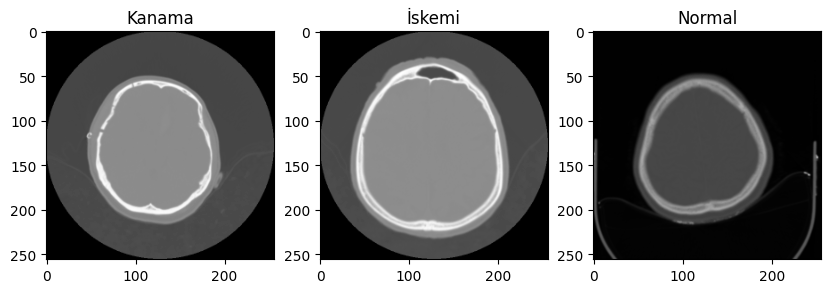

Kanama veri şekli: (1093, 256, 256)
İskemi veri şekli: (1130, 256, 256)
Normal veri şekli: (4427, 256, 256)
Kanama etiketleri: (1093,)
İskemi etiketleri: (1130,)
Normal etiketleri: (4427,)
Görüntü şekilleri: [(256, 256), (256, 256), (256, 256), (256, 256), (256, 256)]


In [9]:

X_train_rgb, y_train, X_val_rgb, y_val = datautil.load_data(target_size)

In [10]:
# Modeli derleme
input_shape = (target_size[0], target_size[1], 1)


seg_model, history = utils.segmentation_model_fit(X_train_rgb, y_train, X_val_rgb, y_val)
# Modeli eğitme

Epoch 1/50


ValueError: in user code:

    File "c:\Python38\lib\site-packages\keras\engine\training.py", line 1160, in train_function  *
        return step_function(self, iterator)
    File "c:\Python38\lib\site-packages\keras\engine\training.py", line 1146, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "c:\Python38\lib\site-packages\keras\engine\training.py", line 1135, in run_step  **
        outputs = model.train_step(data)
    File "c:\Python38\lib\site-packages\keras\engine\training.py", line 994, in train_step
        loss = self.compute_loss(x, y, y_pred, sample_weight)
    File "c:\Python38\lib\site-packages\keras\engine\training.py", line 1052, in compute_loss
        return self.compiled_loss(
    File "c:\Python38\lib\site-packages\keras\engine\compile_utils.py", line 265, in __call__
        loss_value = loss_obj(y_t, y_p, sample_weight=sw)
    File "c:\Python38\lib\site-packages\keras\losses.py", line 152, in __call__
        l

In [ ]:
# Eğitim geçmişini görselleştirme
fig.plot_history(history, 'Segmentation Model Training History')



In [ ]:
fig.sample_visualization( seg_model, X_val_rgb, y_val)



In [ ]:
#model kaydet
# seg_model.save('best_seg_model2.h5')

In [ ]:
# seg_model = tf.keras.models.load_model('best_seg_model.h5')

In [ ]:
# Test verisini yükle
test_images, test_names = utils.load_dicom_data("YarısmaVeriSeti_1.Oturum/DICOM")


In [ ]:
import os
os.makedirs("YarısmaVeriSeti_1.Oturum/MASKS", exist_ok=True)

In [ ]:

# Tahmin yap ve kaydet
for i, img in enumerate(test_images):
    # Girdi resminin boyutunu (1, H, W, 1) şekline getiriyor. (Batch ve kanal ekseni ekleniyor.)

    # Model çıktısı (1, H, W, 1) olur. squeeze() ile (H, W) şekline indirgeniyor.
    pred_mask = seg_model.predict(img[np.newaxis, ..., np.newaxis]).squeeze()

    # Maskede tahmin edilen değerleri eşikleyip (0.5 üstü = 1), piksel değerlerine (0 veya 255) çeviriyor.


    mask_img = Image.fromarray(((pred_mask > 0.5)*255).astype(np.uint8))
    #PIL ile resmi .png olarak kaydediyor.


    mask_img.save(f"YarısmaVeriSeti_1.Oturum/MASKS/{test_names[i].split('.')[0]}_seg_mask.png")